# Goals
Be able to predict individuals who will have a stroke based on health records.
Which factor correlates the strongest with stroke risk?


In [2]:
# data loading and library imports
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go
import mylib

from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency, skew

warnings.filterwarnings('ignore')

output_dir = '../../../public/graphs/stroke'
os.makedirs(output_dir, exist_ok=True)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("\nDATA LOADING")

df = pd.read_csv('../../data/healthcare-dataset-stroke-data.csv')
df


DATA LOADING


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# I. Data Cleaning and Preparation

In [3]:
# Information on the dimensions, column titles, and data types (of the columns)
print(f"Dataset Shape: {df.shape}")
print(f"Dataset Dimesions: {df.columns}")
print(f"Dataset Types: {df.dtypes}")

# 1. Missing Value Analysis
mylib.missing_value_analysis(df)
# only bmi seems to have null/missing values. Let's check its distribution. 
skew_value = df['bmi'].skew()
print("BMI Skewness:", skew_value)
if(skew_value >= .5):
    print("\nModerate-High Skew; Median Imputed Preferred; Amount of Data Affected:", round(df['bmi'].isnull().sum()/(df.shape[0]*.01),4),"%")

df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df

Dataset Shape: (5110, 12)
Dataset Dimesions: Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')
Dataset Types: id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

1. Missing Value Analysis:

     Missing_Count  Missing_Percentage
bmi            201            3.933464
BMI Skewness: 1.0553402052962912

Moderate-High Skew; Median Imputed Preferred; Amount of Data Affected: 3.9335 %


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.1,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [4]:
# I want to change all categorical to category not object. addictionally, I would like to create ordinal varables from some continuous variabler such as age.

# 2. Data Type Validation and Conversion
print("\n2. Data Type Validation:")
print(df.dtypes)

## Converting categorical columns to category type for mem/speed efficiency (usually object takes more memory)
categorical_cols = mylib.get_categorical_cols(df)
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("\nUpdated data type(s):")
print(df.dtypes)



2. Data Type Validation:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Updated data type(s):
id                      int64
gender               category
age                   float64
hypertension            int64
heart_disease           int64
ever_married         category
work_type            category
Residence_type       category
avg_glucose_level     float64
bmi                   float64
smoking_status       category
stroke                  int64
dtype: object


In [5]:
# 3. Outlier Detection
print("\n3. Outlier Detection:")

def detect_outliers(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = (Q3-Q1)*1.5
    lower = Q1-IQR
    upper = Q3+IQR
    
    outliers = df[(df[column] < lower) | (df[column]  > upper)] # returns rows that are an outlier of the column
    return outliers, upper, lower # want to display the upper and lower bound for the post

numeric_cols = mylib.get_numeric_cols(df)

outlier_summary = {}
for col in numeric_cols:
    outliers, upper, lower = detect_outliers(df, col)
    outlier_summary[col] = {
        'outlier_count': len(outliers),
        'outlier_percentage': (len(outliers) / len(df)) * 100,
        'lower_bound': lower,
        'upper_bound': upper
    }
print("Outlier Summary:")
for col, info in outlier_summary.items():
    print(f"  {col}: {info['outlier_count']} outliers ({info['outlier_percentage']:.1f}%)")


3. Outlier Detection:
Outlier Summary:
  id: 0 outliers (0.0%)
  age: 0 outliers (0.0%)
  hypertension: 498 outliers (9.7%)
  heart_disease: 276 outliers (5.4%)
  avg_glucose_level: 627 outliers (12.3%)
  bmi: 126 outliers (2.5%)
  stroke: 249 outliers (4.9%)


In [6]:
import statsmodels.api as sm

# # 4. Data Consistency Checks
# print("\n4. Data Consistency Checks:")

# # Check for logical inconsistencies
# for col in numeric_cols:
#     print(f"Daily_Minutes_Spent range: {df['Daily_Minutes_Spent'].min()} - {df['Daily_Minutes_Spent'].max()}")
#     print(f"Posts_Per_Day range: {df['Posts_Per_Day'].min():.1f} - {df['Posts_Per_Day'].max():.1f}")
#     print(f"Likes_Per_Day range: {df['Likes_Per_Day'].min()} - {df['Likes_Per_Day'].max()}")
#     print(f"Follows_Per_Day range: {df['Follows_Per_Day'].min()} - {df['Follows_Per_Day'].max()}")

# Remove Outliers
# df_clean = df.copy()
# for col in numeric_columns:
#     if col in df.columns and outlier_summary[col]['outlier_percentage'] > 5:
#         outliers, lower, upper = detect_outliers(df, col)
#         df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

# print(f"\nRecords after outlier removal: {len(df_clean)} (from {len(df)})")

print("\nOutliers will be kept for predictive accuracy.")

print("\nCANNOT DO Box-Cox Transformation; Binary Response Variable (Stroke)")

# id column dropped; will not help us with analysis
df = df.drop(columns=['id'])


Outliers will be kept for predictive accuracy.

CANNOT DO Box-Cox Transformation; Binary Response Variable (Stroke)


# II. Exploratory Data Analysis (EDA)

Dataset shape: (5110, 11)

Column names:
 ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             5110 non-null   category
 1   age                5110 non-null   float64 
 2   hypertension       5110 non-null   category
 3   heart_disease      5110 non-null   category
 4   ever_married       5110 non-null   category
 5   work_type          5110 non-null   category
 6   Residence_type     5110 non-null   category
 7   avg_glucose_level  5110 non-null   float64 
 8   bmi                5110 non-null   float64 
 9   smoking_status     5110 non-null   category
 10  stroke             5110 non-null   category
dtypes: category(8), float6

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110,5110.000000,5110.0,5110.0,5110,5110,5110,5110.000000,5110.000000,5110,5110.0
unique,3,NaN,2.0,2.0,2,5,2,NaN,NaN,4,2.0
top,Female,NaN,0.0,0.0,Yes,Private,Urban,NaN,NaN,never smoked,0.0
freq,2994,NaN,4612.0,4834.0,3353,2925,2596,NaN,NaN,1892,4861.0
mean,NaN,43.226614,NaN,NaN,NaN,NaN,NaN,106.147677,28.862035,NaN,NaN
std,NaN,22.612647,NaN,NaN,NaN,NaN,NaN,45.283560,7.699562,NaN,NaN
min,NaN,0.080000,NaN,NaN,NaN,NaN,NaN,55.120000,10.300000,NaN,NaN
25%,NaN,25.000000,NaN,NaN,NaN,NaN,NaN,77.245000,23.800000,NaN,NaN
50%,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,91.885000,28.100000,NaN,NaN
75%,NaN,61.000000,NaN,NaN,NaN,NaN,NaN,114.090000,32.800000,NaN,NaN



Unique values per column:
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Missing Values Summary:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


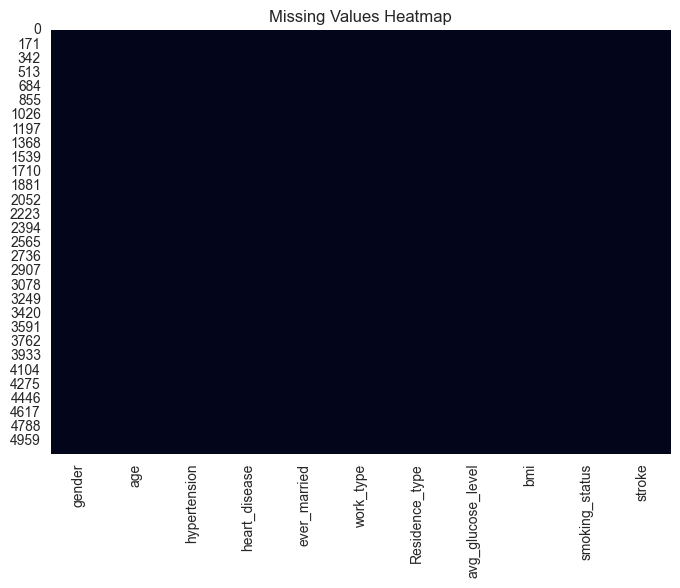


Duplicate Rows: 0

Value counts for gender:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Value counts for hypertension:
hypertension
0    4612
1     498
Name: count, dtype: int64

Value counts for heart_disease:
heart_disease
0    4834
1     276
Name: count, dtype: int64

Value counts for ever_married:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

Value counts for work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Value counts for Residence_type:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

Value counts for smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

Value counts for stroke:
stroke
0    4861
1     249
Name: count, dtype: int64


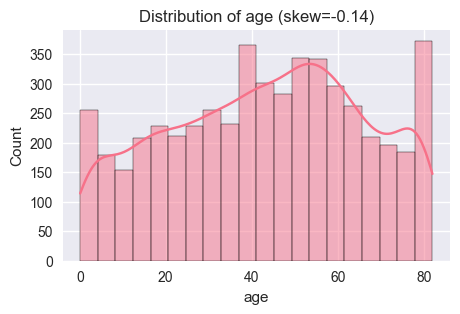

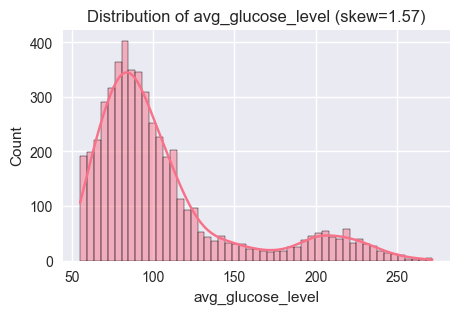

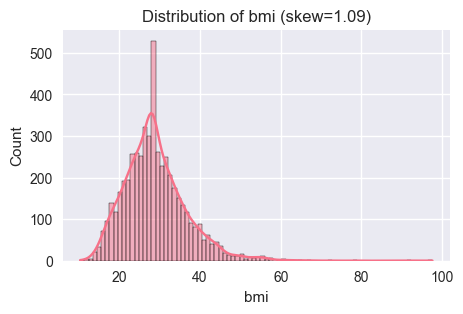

Left Skewed Distributions: ['age']
Right Skewed Distributions: ['avg_glucose_level', 'bmi']


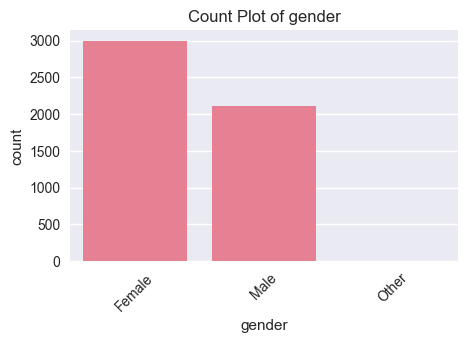

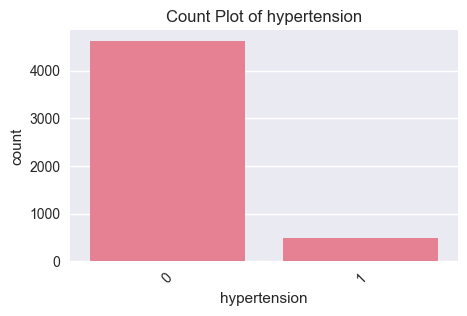

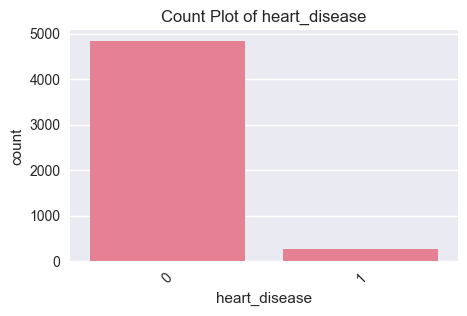

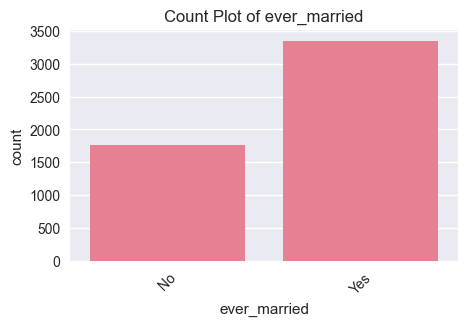

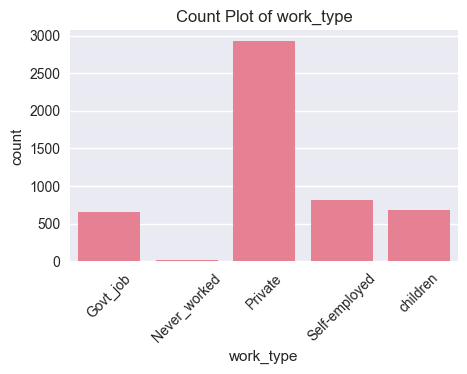

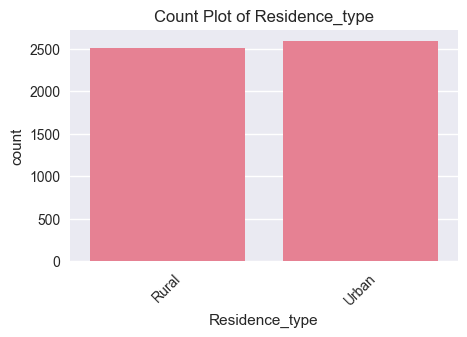

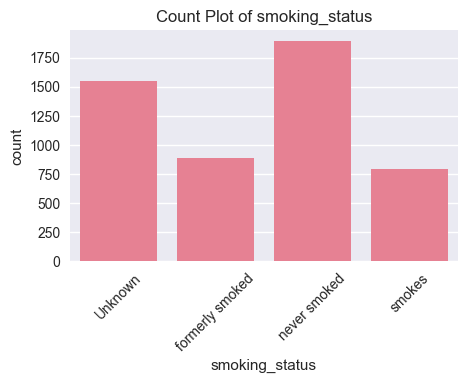

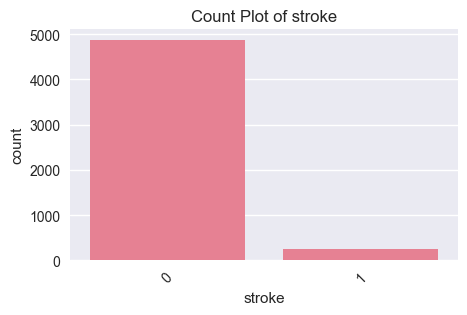

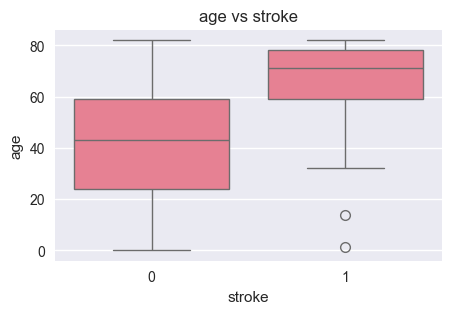

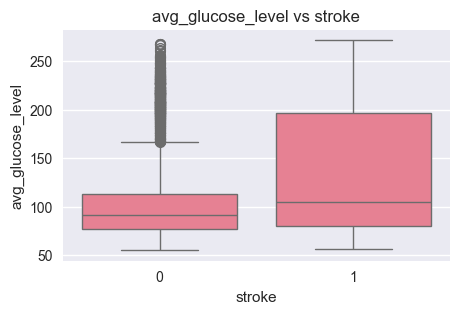

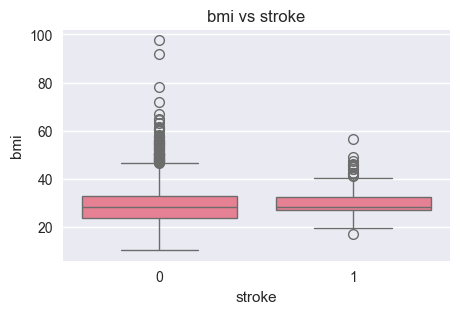


Chi-square test for gender vs stroke:
p-value = 0.7895


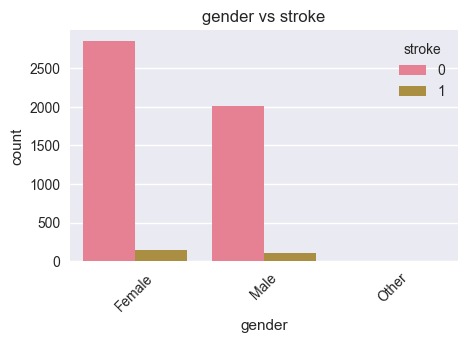


Chi-square test for hypertension vs stroke:
p-value = 0.0000


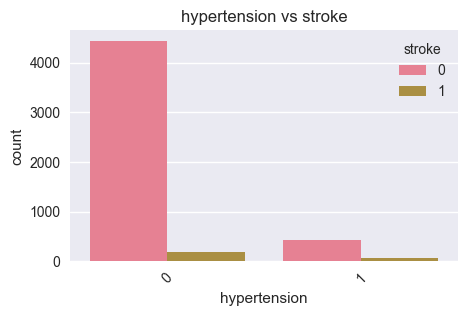


Chi-square test for heart_disease vs stroke:
p-value = 0.0000


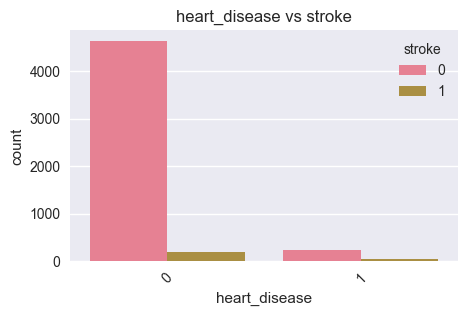


Chi-square test for ever_married vs stroke:
p-value = 0.0000


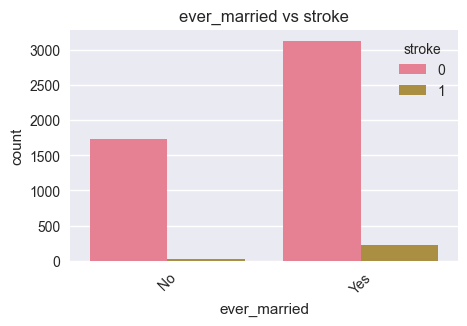


Chi-square test for work_type vs stroke:
p-value = 0.0000


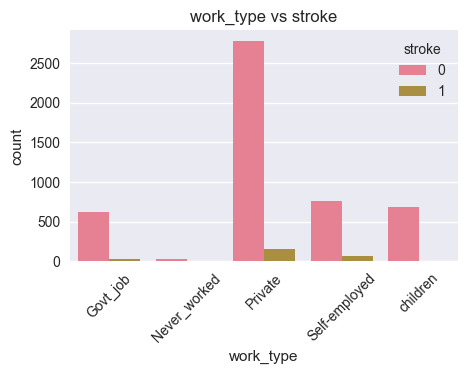


Chi-square test for Residence_type vs stroke:
p-value = 0.2983


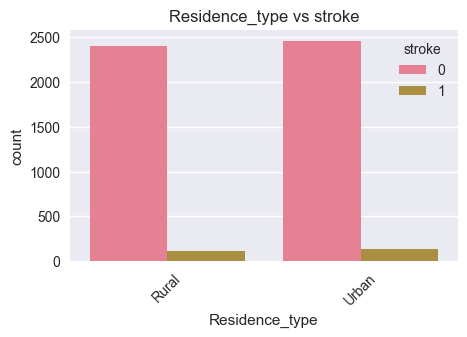


Chi-square test for smoking_status vs stroke:
p-value = 0.0000


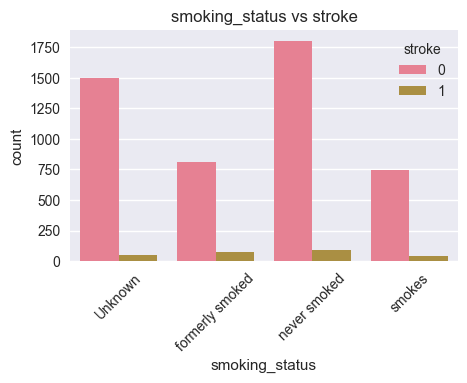


Chi-square test for stroke vs stroke:
p-value = 0.0000


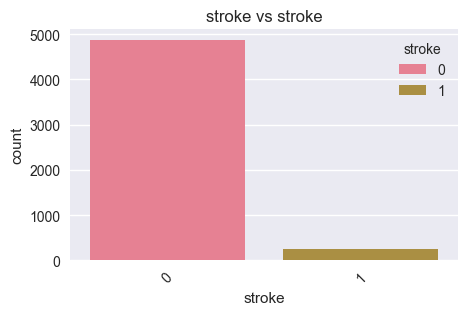


Chi-square Test Summary:


,Variable,Chi2,p-value,Significance,Degrees of Freedom
1,hypertension,81.605,0.00000,Significant (p < 0.05),1
2,heart_disease,90.260,0.00000,Significant (p < 0.05),1
3,ever_married,58.924,0.00000,Significant (p < 0.05),1
4,work_type,49.164,0.00000,Significant (p < 0.05),4
6,smoking_status,29.147,0.00000,Significant (p < 0.05),3
5,Residence_type,1.082,0.29833,Not Significant,1
0,gender,0.473,0.78955,Not Significant,2


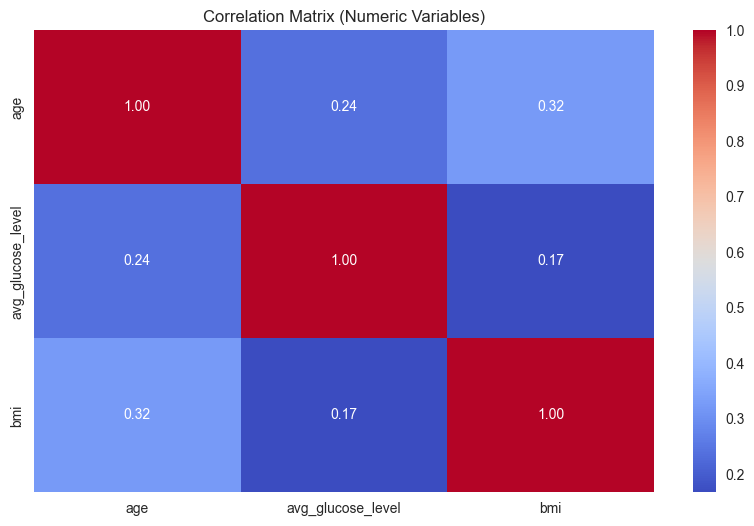

In [7]:
# ---------------------------------------------------------------
# 1. Dataset Overview
# ---------------------------------------------------------------
df_eda = df.copy()
# Identify binary columns (with only two unique values)
binary_cols = [col for col in df_eda.columns if df_eda[col].nunique() == 2]

# Convert them to categorical
for col in binary_cols:
    df_eda[col] = df_eda[col].astype('category')
    
# Basic structure and metadata
print("Dataset shape:", df_eda.shape)
print("\nColumn names:\n", df_eda.columns.tolist())

print("\nData types and non-null counts:")
df_eda.info()

print("\nDescriptive statistics (numeric and categorical):")
display(df_eda.describe(include='all'))

# Unique counts per column
print("\nUnique values per column:")
print(df_eda.nunique())

# Quick preview
display(df_eda.head())

# ---------------------------------------------------------------
# 2. Data Quality Checks
# ---------------------------------------------------------------

# Missing values
print("\nMissing Values Summary:")
print(df_eda.isna().sum())

sns.heatmap(df_eda.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Duplicates
print(f"\nDuplicate Rows: {df_eda.duplicated().sum()}")

# Inconsistent category levels
categorical_cols = df_eda.select_dtypes('category').columns.tolist()
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df_eda[col].value_counts())

# ---------------------------------------------------------------
# 3. Univariate Analysis
# ---------------------------------------------------------------

# --- Numeric Features ---
numeric_cols = df_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()

left_skew = list()
right_skew = list()

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df_eda[col], kde=True)
    plt.title(f"Distribution of {col} (skew={df_eda[col].skew():.2f})")
    plt.show()
    if df_eda[col].skew() < 0:
        left_skew.append(col)
    else:
        right_skew.append(col)
        
print(f"Left Skewed Distributions: {left_skew}")  
print(f"Right Skewed Distributions: {right_skew}")        

# --- Categorical Features ---
for col in categorical_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, data=df_eda)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

# ---------------------------------------------------------------
# 4. Bivariate Analysis
# ---------------------------------------------------------------

# Numeric vs Target (stroke)
target = 'stroke'

for col in numeric_cols:
    if col != target:
        plt.figure(figsize=(5,3))
        sns.boxplot(x=target, y=col, data=df_eda)
        plt.title(f"{col} vs {target}")
        plt.show()

# Categorical vs Target
for col in categorical_cols:
    cross_tab = pd.crosstab(df_eda[col], df_eda[target])
    print(f"\nChi-square test for {col} vs {target}:")
    chi2, p, dof, expected = chi2_contingency(cross_tab)
    print(f"p-value = {p:.4f}")
    
    plt.figure(figsize=(5,3))
    sns.countplot(x=col, hue=target, data=df_eda)
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()

table = mylib.chi_summary_table(df_eda, categorical_cols, target)
# ---------------------------------------------------------------
# 5. Correlation & Multivariate Checks
# ---------------------------------------------------------------

corr = df_eda.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numeric Variables)")
plt.show()
    
# ---------------------------------------------------------------
# 6. Insights Summary (manual notes)
# ---------------------------------------------------------------
# There are 6 categorical vars (including stroke), and 5 numerical in total in a dataset shape of 5110 x 11.
# The unique values per column look reasonable, and duplicates or missing values are not a concern (0)
# Left Skewed Distributions: ['age']
# Right Skewed Distributions: ['avg_glucose_level', 'bmi']

# III. Model 

In [ ]:
print("Since the Response Variable (Stroke, yes or no category), we should use logistic regression.")

# One-hot encode all categorical columns
df_encoded = pd.get_dummies(df, drop_first=True, dtype=float)

# Define X (predictors) and y (response)
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

# Add intercept
X = sm.add_constant(X)
X.dtypes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = sm.Logit(y_train, X_train)
result = model.fit()
print(result.summary())

# Model diagnostics
print("\n--- Model Diagnostics ---")
print(f"AIC: {result.aic:.2f}")
print(f"Log-Likelihood: {result.llf:.2f}")
print(f"Pseudo R² (McFadden): {1 - result.llf / result.llnull:.3f}")

# Multicollinearity Check
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n--- Variance Inflation Factors (VIF) ---")
print(vif)

# If necessary, create a new model to compare the AICs

Since the Response Variable (Stroke, yes or no category), we should use logistic regression.
         Current function value: 0.155068
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 4088
Model:                          Logit   Df Residuals:                     4071
Method:                           MLE   Df Model:                           16
Date:                Tue, 28 Oct 2025   Pseudo R-squ.:                  0.2032
Time:                        11:49:48   Log-Likelihood:                -633.92
converged:                      False   LL-Null:                       -795.55
Covariance Type:            nonrobust   LLR p-value:                 3.793e-59
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const      

## Predictions


--- Odds Ratios ---
                          Variable    Odds Ratio
2                     hypertension  1.586873e+00
12              work_type_children  1.382585e+00
16           smoking_status_smokes  1.293284e+00
3                    heart_disease  1.223439e+00
14  smoking_status_formerly smoked  1.145341e+00
13            Residence_type_Urban  1.084850e+00
1                              age  1.077049e+00
6                      gender_Male  1.066570e+00
10               work_type_Private  1.054295e+00
4                avg_glucose_level  1.003909e+00
5                              bmi  1.000406e+00
15     smoking_status_never smoked  9.249577e-01
11         work_type_Self-employed  7.894980e-01
8                 ever_married_Yes  7.570465e-01
0                            const  4.730623e-04
9           work_type_Never_worked  2.381960e-04
7                     gender_Other  1.238174e-25

Confusion Matrix (Test):
[[972   0]
 [ 49   1]]

Accuracy: 0.952054794520548

Classification Rep

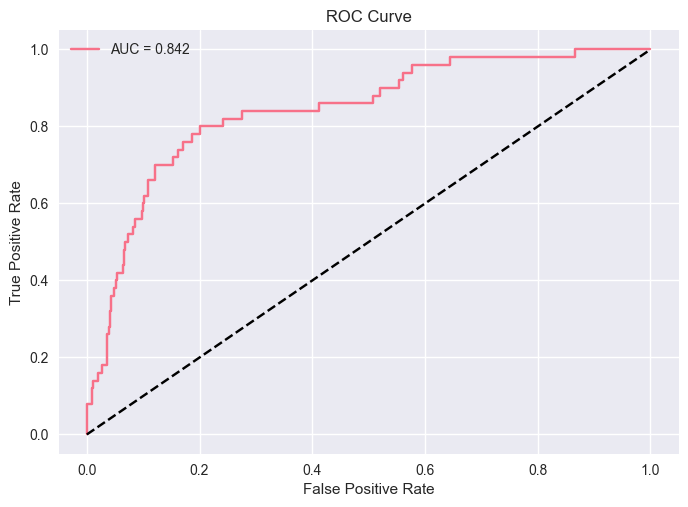

The AUC of our model is 0.84, which means it has a relatively accurate true positive rate


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Odds ratios
odds_ratios = pd.DataFrame({
    "Variable": result.params.index,
    "Odds Ratio": np.exp(result.params.values)
}).sort_values(by="Odds Ratio", ascending=False)

print("\n--- Odds Ratios ---")
print(odds_ratios)

# Predictions
y_pred = result.predict(X_test)
y_pred_to_binary = (y_pred >= 0.5).astype(int)

# Evaluation metrics
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_to_binary))

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_to_binary):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_to_binary))

# ROC-AUC
auc = roc_auc_score(y_test, y_pred)
print(f"ROC-AUC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

if (auc > 0.8):
    print(f"The AUC of our model is {auc:.2f}, which means it has a HIGH descrimination ability.")
elif (auc > 0.6):
    print(f"The AUC of our model is {auc:.2f}, which means it has an ACCEPTABLE descrimination ability.")
else:
    print(f"The AUC is {auc:.2f}, which is below 0.51, indicating a POOR descrimination ability (as good as random guessing).")

# Conclusion
Our logistic regression model demonstrates an acceptable ability to discriminate between individuals who are likely and unlikely to experience a stroke, with an ROC-AUC of approximately 0.84.

The most influential predictors include age, hypertension, and average glucose level — all of which increase the odds of stroke occurrence. Based on the results of our model summary (particularly, the coefficients and p values)

However, while the model provides insight into risk factors, it should not be used as a standalone diagnostic tool.
It highlights individuals at higher risk, but further medical evaluation would be necessary for clinical decision-making.